In [1]:
import numpy as np                # numerical calculations
import pandas as pd               # data handling
import matplotlib.pyplot as plt   # plotting graphs
import seaborn as sns             # advanced visualization

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Housing Price Linear /Housing linear regression.csv')

In [3]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [5]:
print(df.isnull().sum())   # count missing values in each column

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [20]:
print(df['price'].max())
print(df['price'].min())
print(df['bedrooms'].max())
print(df['bedrooms'].min())

7700000.0
75000.0
33
0


**Define Features and Target**

In [36]:
# X = df.drop('price', axis=1)   # all columns except price (independent variables should be target as x)
# y = df['price']

X = df[['bedrooms']] #Independent Variable
y = df['price']

**Train Test Split**

In [48]:
from sklearn.model_selection import train_test_split   # import split function
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train Linear Regression Model**

In [50]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()   # create linear regression object
model.fit(X_train, y_train)

LinearRegression()

**Make Predictions**

In [53]:
y_pred = model.predict(X_test)   # predict house prices using test data
print(y_pred[:20])               # print first 20 predicted prices

[613509.82608432 733222.43765285 613509.82608432 493797.21451578
 493797.21451578 613509.82608432 613509.82608432 493797.21451578
 493797.21451578 374084.60294724 493797.21451578 493797.21451578
 374084.60294724 493797.21451578 493797.21451578 613509.82608432
 852935.04922139 613509.82608432 613509.82608432 613509.82608432]


**Calculate Errors**

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error   # import metrics

**Mean Absolute Error**

In [55]:
mae = mean_absolute_error(y_test, y_pred)   #average error
print("Mean Absolute Error:", mae)

Mean Absolute Error: 226441.46417253063


**Mean Squared Error**

In [56]:
mse = mean_squared_error(y_test, y_pred)   #detect large errors
print("Mean Squared Error:", mse)

Mean Squared Error: 137071164729.91542


**Root Mean Squared Error**

In [66]:
rmse = np.sqrt(mse)   #Converts error back to original unit (price)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 370231.2314350525


**Scatter Plot (Actual vs Predicted)**

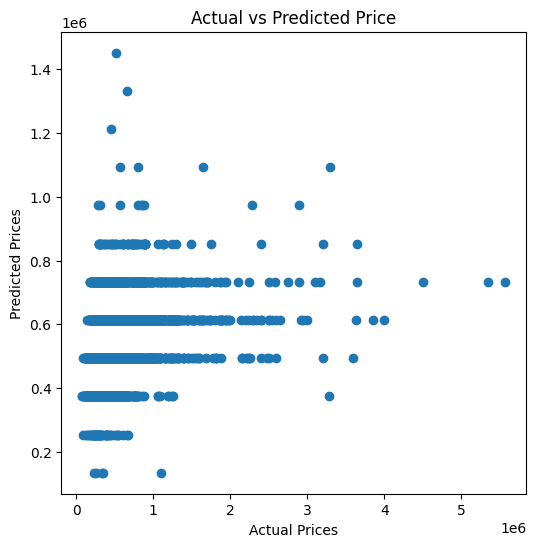

In [67]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Price")
plt.show()

**Residual Plot**

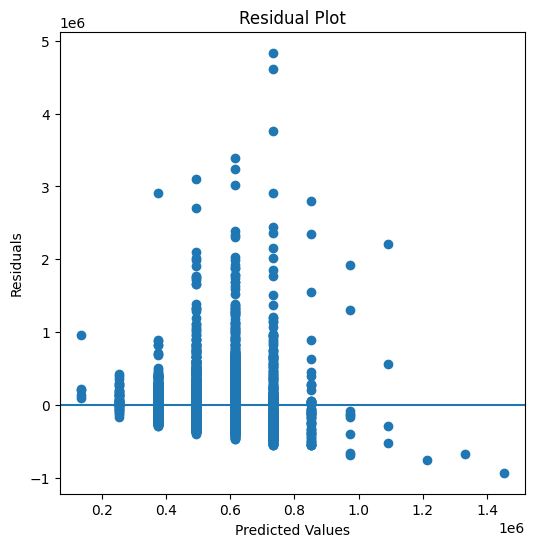

In [68]:
residuals = y_test - y_pred      # difference between actual and predicted
plt.figure(figsize=(6,6))        # figure size
plt.scatter(y_pred, residuals)   # residual scatter plot
plt.axhline(y=0)                 # horizontal reference line
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Actual vs Predicted Line Graph**

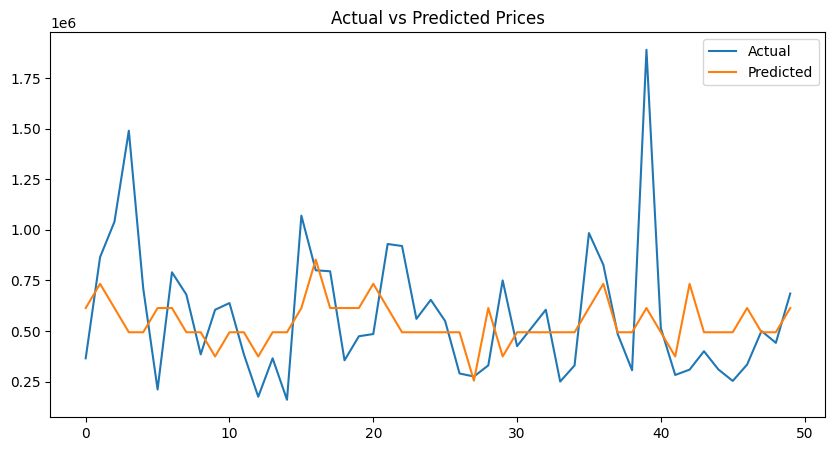

In [61]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")         # first 50 actual prices
plt.plot(y_pred[:50], label="Predicted")             # first 50 predicted prices
plt.legend()                                         # lines representation
plt.title("Actual vs Predicted Prices")
plt.show()